In [1]:
import numpy as np
import pandas as pd
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
import seaborn as sns

# Loading Data

In [2]:
df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [3]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

In [ ]:
df_train.head(50)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

#

In [6]:
# Fit the label encoder to the classes (industry names)
from sklearn.preprocessing import LabelEncoder

# ls = []
# for i in df_train['industry']:
#     ls.append(i)

le = LabelEncoder()
le.fit(df_train['industry'])
list(le.classes_)
le.transform(le.classes_)
# list(le.inverse_transform([2, 2, 1]))

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24])

In [7]:
y_train = None # encode labels
y_val =  None # encode labels

le.fit(df_train['industry'])
y_train = le.transform(df_train['industry'])
print(y_train)

le.fit(df_val['industry'])
y_val = le.transform(df_val['industry'])
print(y_val)

missing = set(y_val) - set(y_train)
print(missing)

[10 21  5 ... 15  6 16]
[ 2 23 15 ...  5  2 17]
set()


# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

In [9]:
# Plot the class distribution or provide a table that shows how many times each class (industry) appears
# Describe your findings
from collections import Counter

le.fit(df_train['industry'])
y_train = le.transform(df_train['industry'])
print(y_train)
counts = Counter(int(x) for x in y_train)
print(counts)

[10 21  5 ... 15  6 16]
Counter({15: 7604, 2: 2805, 17: 1742, 10: 1740, 21: 1390, 20: 1384, 8: 1174, 5: 1037, 11: 956, 12: 911, 1: 874, 16: 827, 18: 825, 3: 726, 4: 591, 6: 591, 0: 572, 19: 545, 23: 528, 24: 504, 9: 387, 14: 264, 13: 206, 22: 194, 7: 158})


### PCA - Dimensionality reduction and visualization

(10, 21, 5, 15, 12, 24, 17, 19, 14, 11, 3, 2, 4, 20, 16, 18, 0, 22, 9, 23, 13, 8, 6, 1, 7)
(1740, 1390, 1037, 7604, 911, 504, 1742, 545, 264, 956, 726, 2805, 591, 1384, 827, 825, 572, 194, 387, 528, 206, 1174, 591, 874, 158)


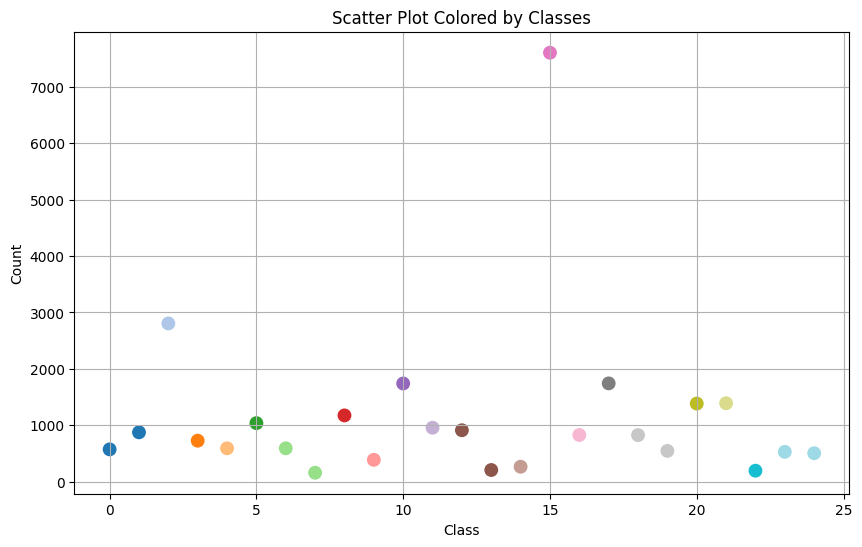

In [16]:
# Performa a PCA and plot the projected data. Color the scatter plot based on the classes
# Analyse what you see
import matplotlib.pyplot as plt

x, y = zip(*counts.items())

print(x)
print(y)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, c=x, cmap='tab20', s=80)

plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Scatter Plot Colored by Classes')
plt.grid(True)

# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

In [ ]:
# your code

df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

y_train = df_train['industry']
y_val   = df_val['industry']

le = LabelEncoder()
y_train_encode = le.fit_transform(y_train)
y_val_encode   = le.transform(y_val)

# 2 Models
log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

log_reg.fit(X_train, y_train_encode)
knn.fit(X_train, y_train_encode)

# predict
y_pred_log = log_reg.predict(X_val)
y_pred_knn = knn.predict(X_val)

# Accuracy & F1
acc_log = accuracy_score(y_val_encode, y_pred_log)
f1_log = f1_score(y_val_encode, y_pred_log, average='weighted')

acc_knn = accuracy_score(y_val_encode, y_pred_knn)
f1_knn = f1_score(y_val_encode, y_pred_knn, average='weighted')


print("📊 Logistic Regression:")
print(f"Accuracy: {acc_log:.4f}")
print(f"F1-score: {f1_log:.4f}")

print("\n📊 KNN Classifier:")
print(f"Accuracy: {acc_knn:.4f}")
print(f"F1-score: {f1_knn:.4f}")


📊 Logistic Regression:
Accuracy: 0.7720
F1-score: 0.7663

📊 KNN Classifier:
Accuracy: 0.7531
F1-score: 0.7495


# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of a industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- The designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

In [9]:
def confidence_weighted_f1(y_true, y_pred, confidence):
    # Weight all predictions, not just positives
    weighted_tp = np.sum(confidence * (y_pred == 1) * (y_true == 1))
    weighted_fp = np.sum(confidence * (y_pred == 1) * (y_true == 0))
    weighted_fn = np.sum(confidence * (y_pred == 0) * (y_true == 1))
    
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1

In [ ]:
import numpy as np
import pandas as pd
import ast

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)

y_train = df_train['industry']
y_val   = df_val['industry']

le = LabelEncoder()
y_train_encode = le.fit_transform(y_train)
y_val_encode   = le.transform(y_val)

# Model
log_reg = LogisticRegression(max_iter=1000, n_jobs=-1)
log_reg.fit(X_train, y_train_encode)

# predict
probs  = log_reg.predict_proba(X_val)
y_pred = np.argmax(probs, axis=1)
y_confidence = np.max(probs, axis=1)

In [17]:
result = (y_pred, y_confidence)
print(result)

acc_new = confidence_weighted_f1(y_val_encode, y_pred, y_confidence)
print(f"f1: {acc_new}")

f1_true = f1_score(y_val_encode, y_pred, average='weighted')
print("sklearn_F1:", f1_true)

(array([ 2, 23, 15, ..., 21,  2, 17], shape=(3171,)), array([0.75218037, 0.74381998, 0.92277084, ..., 0.77583976, 0.71578522,
       0.8126955 ], shape=(3171,)))
f1: 1.0
sklearn_F1: 0.7662843100318403
